In [2]:
#1."To perform initial exploratory data analysis (EDA) on the real estate sales dataset
#   by loading, cleaning, and summarizing the data to prepare it for deeper statistical or visual analysis."


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

path="C:/Users/Piyush Verma/Downloads/Real_Estate_Sales_2001-2022_GL.csv"
df = pd.read_csv(path)

print(" Basic Info:")
print(df.info())

print("\n Missing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe(include='all'))


df['Date Recorded'] = pd.to_datetime(df['Date Recorded'], errors='coerce')

df_cleaned = df.dropna(thresh=len(df.columns) - 3)
df_cleaned.fillna(method='ffill', inplace=True)

if 'Date' in df_cleaned.columns:
    df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], errors='coerce')

print("\nStatistical Summary:")
print(df_cleaned.describe(include='all'))

import warnings
warnings.filterwarnings('ignore')

 Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306043 entries, 0 to 306042
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Serial Number     306043 non-null  int64  
 1   List Year         306043 non-null  int64  
 2   Date Recorded     306043 non-null  object 
 3   Town              306043 non-null  object 
 4   Address           306040 non-null  object 
 5   Assessed Value    306043 non-null  float64
 6   Sale Amount       306043 non-null  float64
 7   Sales Ratio       306043 non-null  float64
 8   Property Type     294403 non-null  object 
 9   Residential Type  278460 non-null  object 
 10  Non Use Code      83982 non-null   object 
 11  Assessor Remarks  68079 non-null   object 
 12  OPM remarks       10416 non-null   object 
 13  Location          153441 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 32.7+ MB
None

 Missing Values:
Serial Number         

In [3]:
import pandas as pd

# 1. Initial check
print("Initial shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

# 2. Strip whitespace from column names
df.columns = df.columns.str.strip()

# 3. Drop empty rows and duplicates
df = df.dropna(how='all')
df = df.drop_duplicates()

# 4. Parse 'Date' column if it exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 5. Identify columns with '$' symbol
money_cols = df.columns[df.apply(lambda x: x.astype(str).str.contains('$', na=False).any())]

# 6. Remove '$' and ',' then convert to numeric (vectorized, no loop)
df[money_cols] = df[money_cols].replace({'\$': '', ',': ''}, regex=True)
df[money_cols] = df[money_cols].apply(pd.to_numeric, errors='coerce')

# 7. Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 8. Final check
print("Cleaned shape:", df.shape)
print("Missing values after cleaning:\n", df.isnull().sum())
print("Preview:\n", df.head())


Initial shape: (306043, 14)
Missing values:
 Serial Number            0
List Year                0
Date Recorded       121653
Town                     0
Address                  3
Assessed Value           0
Sale Amount              0
Sales Ratio              0
Property Type        11640
Residential Type     27583
Non Use Code        222061
Assessor Remarks    237964
OPM remarks         295627
Location            152602
dtype: int64
Cleaned shape: (306043, 14)
Missing values after cleaning:
 serial_number            0
list_year                0
date_recorded            0
town                306043
address             306020
assessed_value           0
sale_amount              0
sales_ratio              0
property_type       306043
residential_type    306043
non_use_code        306043
assessor_remarks    305984
opm_remarks         306043
location            306043
dtype: int64
Preview:
    serial_number  list_year        date_recorded  town  address  \
0         220008       2022  1675036

In [4]:
# 3."To analyze the distribution of categorical variables in the real estate dataset by displaying the most frequent values for each category."
# Unique value counts for categorical columns
path="C:/Users/Piyush Verma/Downloads/Real_Estate_Sales_2001-2022_GL.csv"
df = pd.read_csv(path)

categorical_cols = ['Town', 'Property Type', 'Residential Type', 'Non Use Code']
for col in categorical_cols:
    print(f"\n Value counts for {col}:")
    print(df[col].value_counts().head(10))





 Value counts for Town:
Town
Stamford         9458
Waterbury        9423
Bridgeport       8823
New Haven        6855
West Hartford    6550
Stratford        6404
Norwalk          6381
Danbury          5871
Greenwich        5695
Hamden           5632
Name: count, dtype: int64

 Value counts for Property Type:
Property Type
Residential      151064
Single Family     93681
Condo             23705
Vacant Land        7824
Two Family         6427
Commercial         5987
Three Family       3056
Apartments         1327
Industrial          795
Four Family         527
Name: count, dtype: int64

 Value counts for Residential Type:
Residential Type
Single Family    200113
Condo             55107
Two Family        14867
Three Family       7037
Four Family        1336
Name: count, dtype: int64

 Value counts for Non Use Code:
Non Use Code
25 - Other                     23618
07 - Change in Property        17380
14 - Foreclosure               15543
08 - Part Interest              6101
01 - Family     

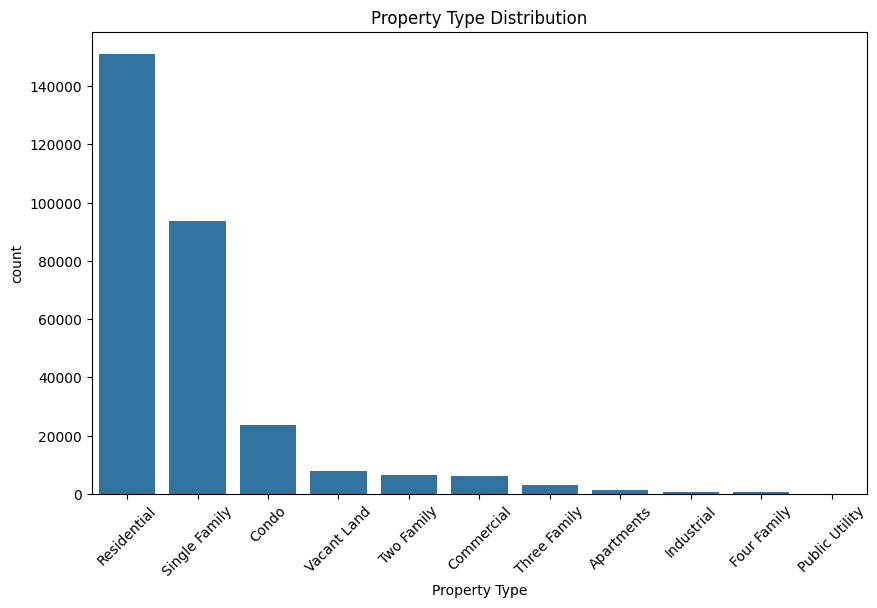

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Property Type', order=df['Property Type'].value_counts().index)
plt.title("Property Type Distribution")
plt.xticks(rotation=45)
plt.show()

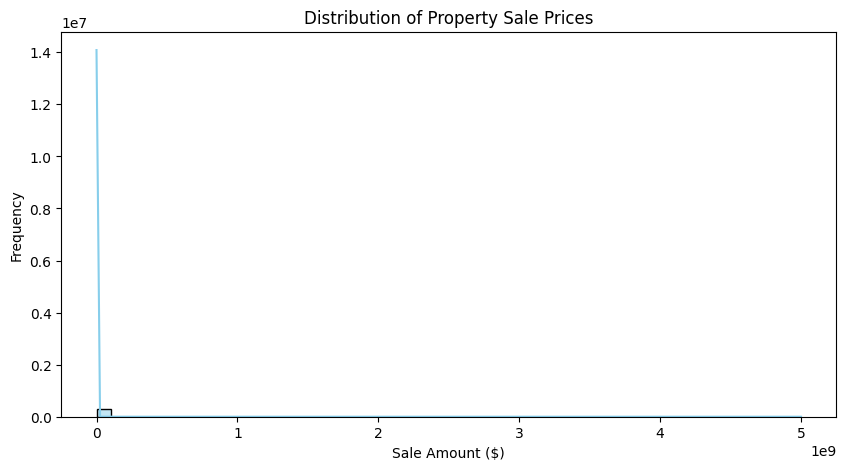

In [6]:
# 4."To visualize the distribution of property sale prices and identify patterns,
#  outliers, or skewness in the sale_amount column using a histogram with a KDE overlay."

# 1. Understand the distribution of property sale prices

plt.figure(figsize=(10, 5))
sns.histplot(df['Sale Amount'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Amount ($)")
plt.ylabel("Frequency")
plt.show()

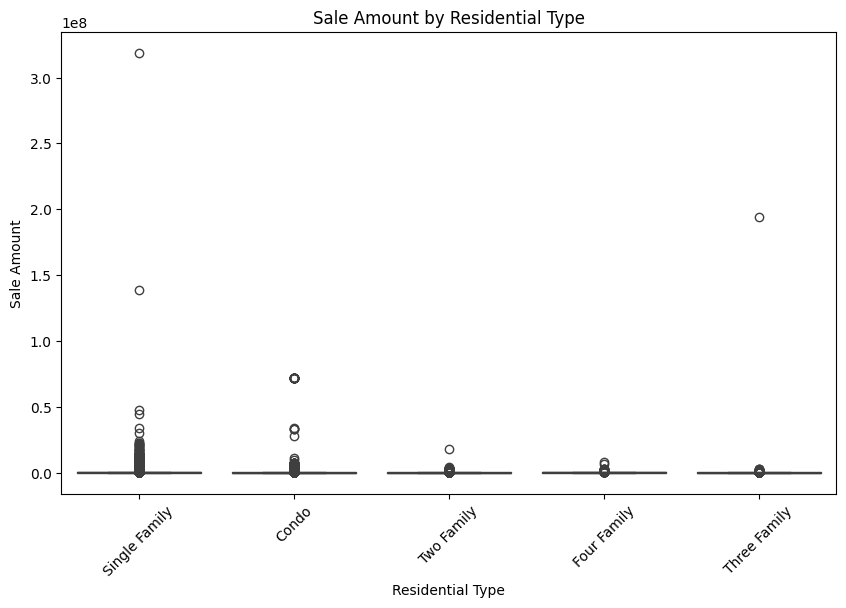

In [7]:
# 5."To compare the distribution and spread of Sale Amount across different Residential Type categories using a box plot."


plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Residential Type', y='Sale Amount')
plt.title("Sale Amount by Residential Type")
plt.xticks(rotation=45)
plt.show()

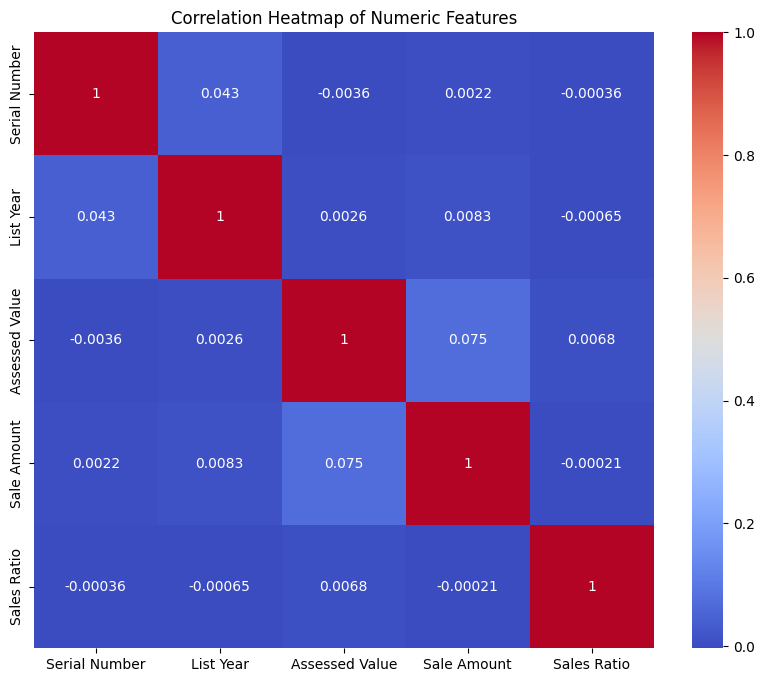

In [8]:
# Explore relationships between numerical features using correlation
# 6."To visualize the strength and direction of relationships between numerical variables in the dataset."

# Correlation heatmap

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


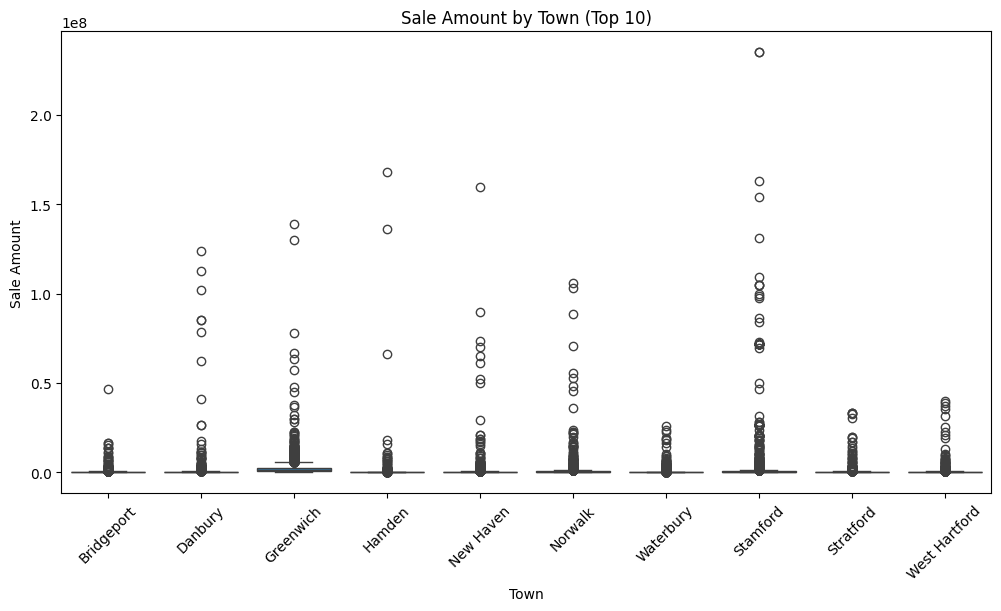

In [9]:
# Sale Amount by Town (top 10 towns only)
# 7."To analyze and compare the distribution of property sale amounts across the top 10 towns with the highest number of sales."
top_towns = df['Town'].value_counts().nlargest(10).index
top_df = df[df['Town'].isin(top_towns)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=top_df, x='Town', y='Sale Amount')
plt.title("Sale Amount by Town (Top 10)")
plt.xticks(rotation=45)
plt.show()

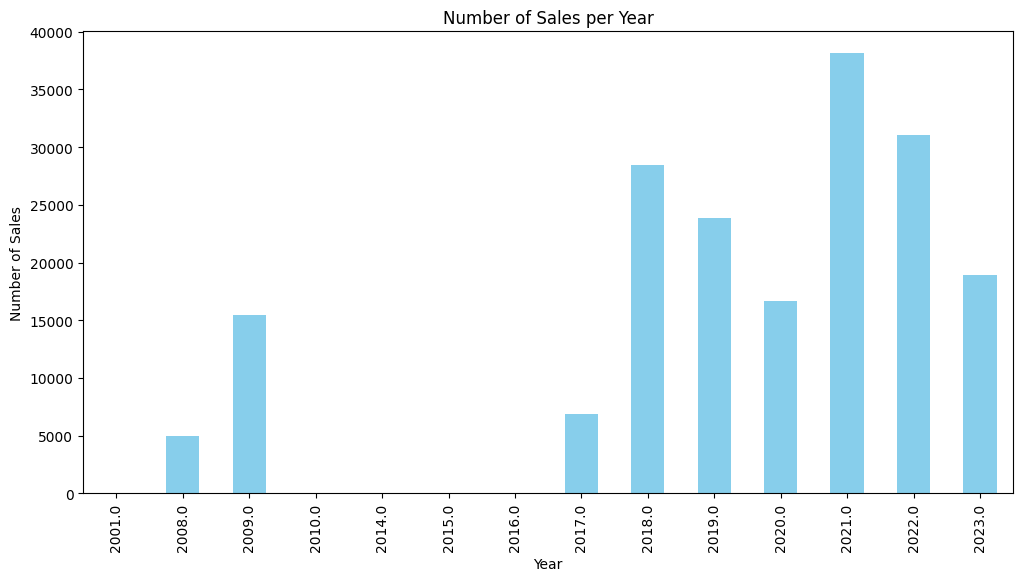

In [19]:
# Convert 'Date Recorded' to datetime format
df['Date Recorded'] = pd.to_datetime(df['Date Recorded'], errors='coerce')

# Extract year
df['Year'] = df['Date Recorded'].dt.year

# Group and count sales per year
yearly_sales = df.groupby('Year')['Sale Amount'].count()

# Plot
plt.figure(figsize=(12, 6))
yearly_sales.plot(kind='bar', color='skyblue')
plt.title("Number of Sales per Year")
plt.xlabel("Year")
plt.ylabel("Number of Sales")
plt.show()


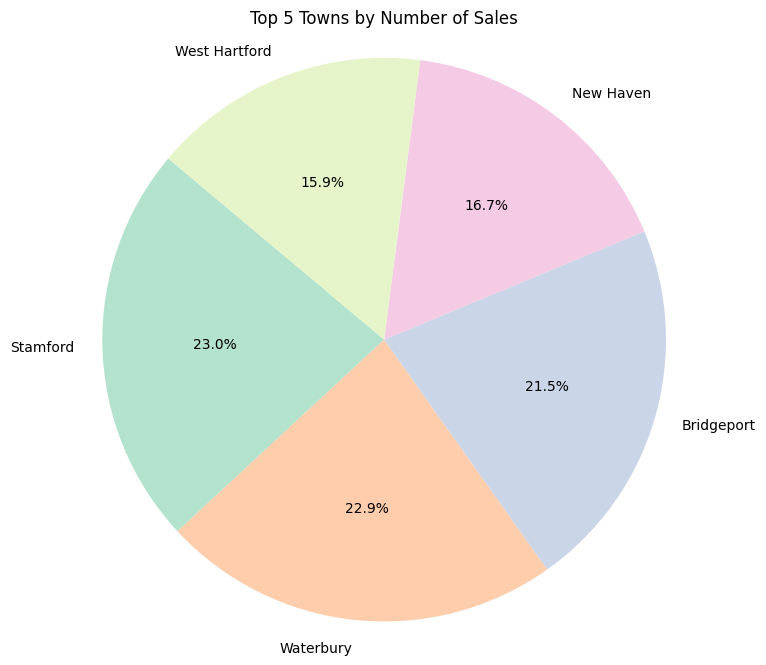

In [10]:
# 9."To identify and visualize the top 5 towns with the highest number of property sales using a pie chart."

import matplotlib.pyplot as plt

# Get top 5 towns by sale count
town_counts = df['Town'].value_counts().nlargest(5)

# pie chart
plt.figure(figsize=(8, 8))
plt.pie(town_counts, labels=town_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel2.colors)
plt.title('Top 5 Towns by Number of Sales')
plt.axis('equal')  # Makes it a perfect circle
plt.show()



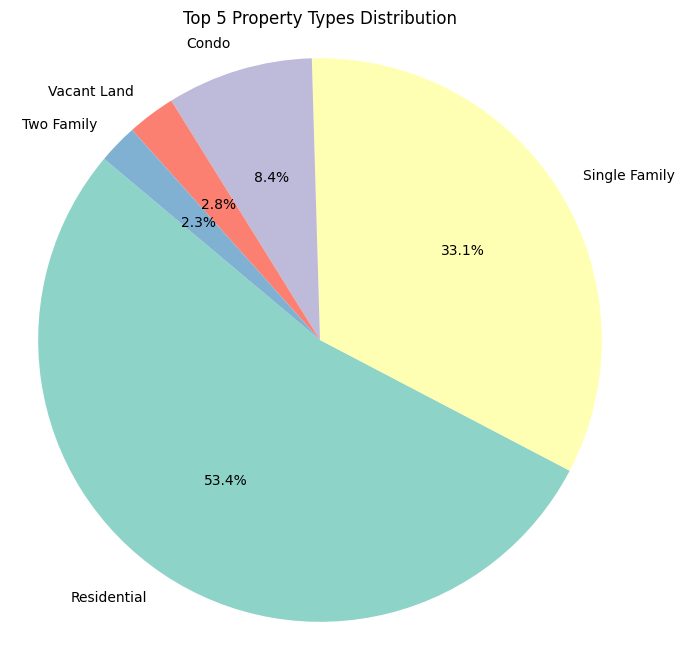

In [11]:
property_counts = df['Property Type'].value_counts().nlargest(5)

plt.figure(figsize=(8, 8))
plt.pie(property_counts, labels=property_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
plt.title('Top 5 Property Types Distribution')
plt.axis('equal')
plt.show()


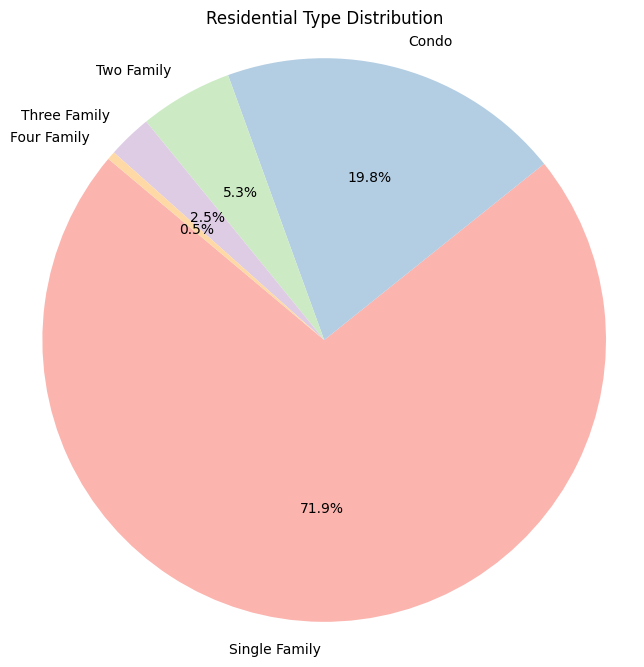

In [12]:
#3. Pie Chart: Residential vs Non-residential Types

res_type_counts = df['Residential Type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(res_type_counts, labels=res_type_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Residential Type Distribution')
plt.axis('equal')
plt.show()

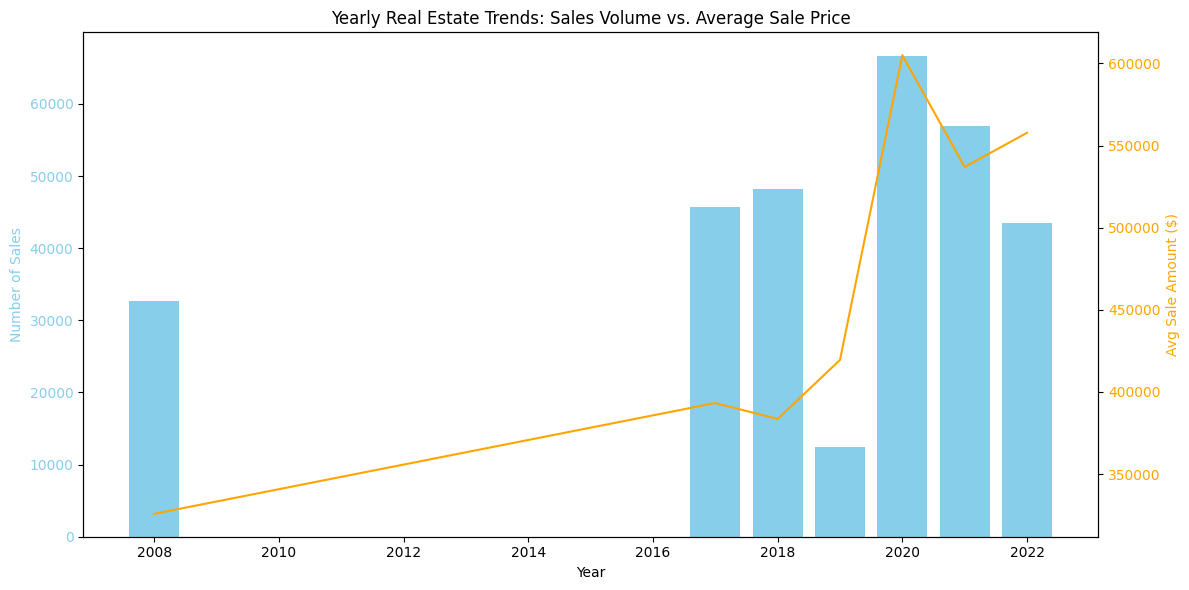

In [13]:
#11.To analyze the trend of the number of sales and the average sale amount over the years.
#This helps in understanding whether the market is getting busier and whether property prices are increasing.

import matplotlib.pyplot as plt
import pandas as pd

# 'list_year' is integer
df['List Year'] = pd.to_numeric(df['List Year'], errors='coerce')

# Drop rows with missing list_year or sale_amount
filtered_df = df.dropna(subset=['List Year', 'Sale Amount'])

# Group by year
yearly_summary = filtered_df.groupby('List Year').agg({'Sale Amount': ['count', 'mean']}).reset_index()

# Flatten column names
yearly_summary.columns = ['List Year', 'sales_count', 'avg_sale_amount']

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for sales count
ax1.bar(yearly_summary['List Year'], yearly_summary['sales_count'], color='skyblue', label='Number of Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Sales', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line chart for average sale amount
ax2 = ax1.twinx()
ax2.plot(yearly_summary['List Year'], yearly_summary['avg_sale_amount'], color='orange', label='Avg Sale Amount')
ax2.set_ylabel('Avg Sale Amount ($)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and legends
plt.title('Yearly Real Estate Trends: Sales Volume vs. Average Sale Price')
fig.tight_layout()
plt.show()



In [14]:
#13.
#1. Z-Test

#To test whether the average sale amount in a specific town (e.g., "HARTFORD") is significantly different from the overall average sale amount.

from statsmodels.stats.weightstats import ztest

# Filter dataset
df_clean = df[(df['Sale Amount'] > 0) & (df['Town'].notnull())]
town_data = df_clean[df_clean['Town'].str.upper() == 'HARTFORD']['Sale Amount']
overall_data = df_clean['Sale Amount']

# Z-test
z_stat, p_value = ztest(town_data, value=overall_data.mean())
print(f"Z-statistic: {z_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in mean Sale Amount for HARTFORD.")
else:
    print("No significant difference in mean Sale Amount for HARTFORD.")



Z-statistic: -11.49
P-value: 0.0000
Significant difference in mean Sale Amount for HARTFORD.
